In [1]:
import sys
print(sys.path)

['/usr/lib/python314.zip', '/usr/lib/python3.14', '/usr/lib/python3.14/lib-dynload', '', '/home/swaraj/python/Plasma/ss/lib/python3.14/site-packages']


In [2]:
import os
sys.path.append(os.path.abspath(".."))

In [3]:
import importlib
from DTTP_resources import psiBfield

importlib.reload(psiBfield)

g = psiBfield.extract_g()
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

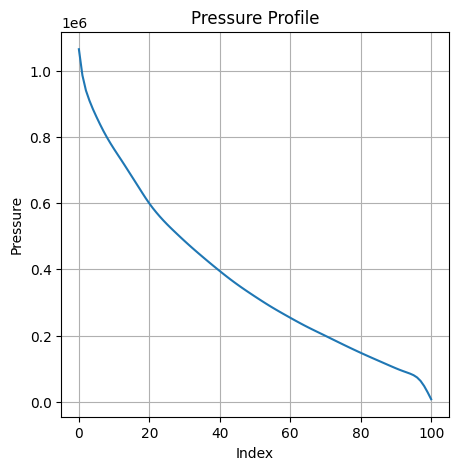

In [5]:
plt.figure(figsize=(5, 5))
plt.plot(g.pres)
plt.xlabel('Index')
plt.ylabel('Pressure')
plt.title('Pressure Profile')
plt.grid()
plt.show()

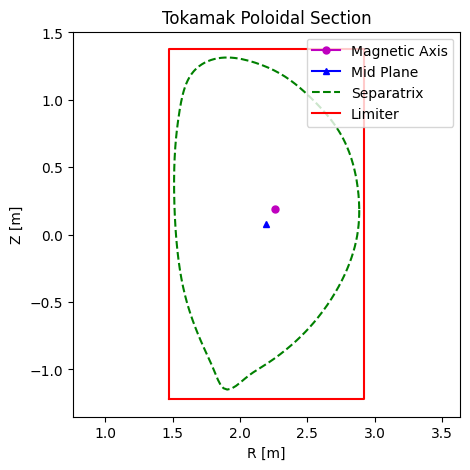

In [6]:
plt.figure(figsize=(5,5))
plt.plot(g.rmaxis, g.zmaxis, 'm', marker = 'o', markersize = 5, label = "Magnetic Axis")
plt.plot(g.rcentr, g.zmid, 'b',marker = '^', markersize = 5, label = "Mid Plane")
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.plot(g.rlim, g.zlim, 'r', label = "Limiter")
plt.title("Tokamak Poloidal Section")
plt.xlim(g.r_grid[:,0][0], g.r_grid[:,0][-1])
plt.ylim(g.z_grid[0,:][0], g.z_grid[0,:][-1])
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

/tmp/ipykernel_125376/1801196969.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


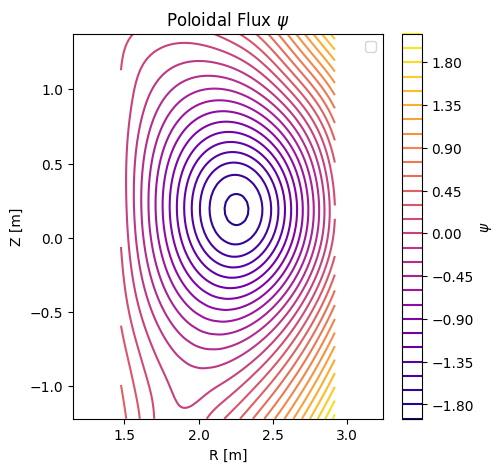

In [7]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, g.psi, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

/tmp/ipykernel_125376/1103649705.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


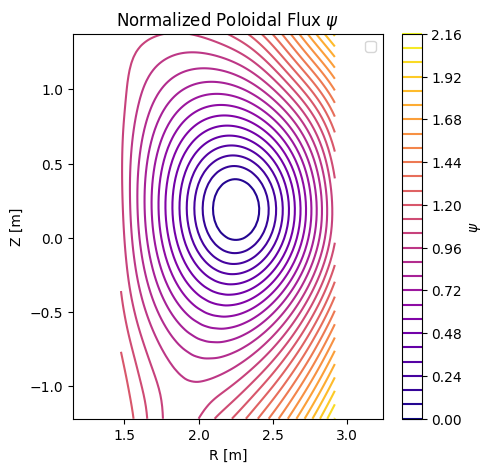

In [8]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, psi_norm, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Normalized Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

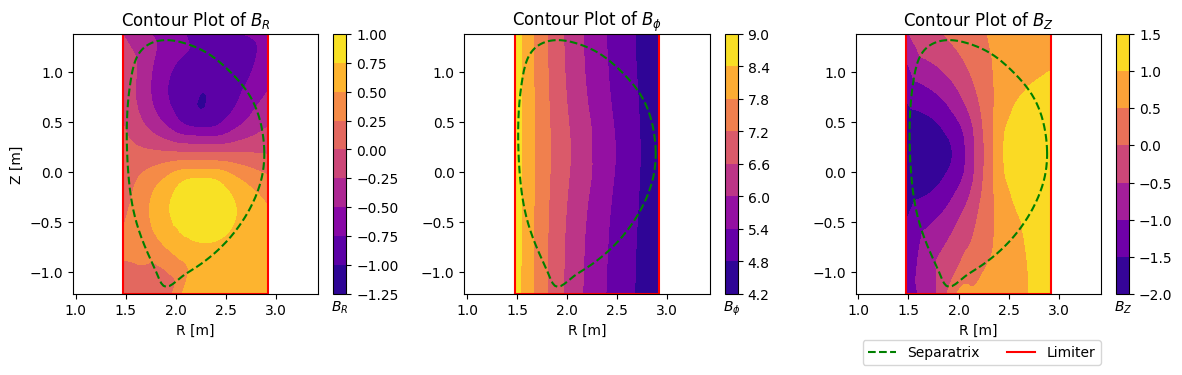

In [9]:
plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.contourf(g.r_grid, g.z_grid, BR, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_R$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_R$')

plt.subplot(1,3,2)
plt.contourf(g.r_grid, g.z_grid, Bphi, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_\phi$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_{\phi}$')

plt.subplot(1,3,3)
plt.contourf(g.r_grid, g.z_grid, BZ, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_Z$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.legend(loc='lower left', ncols=2, bbox_to_anchor=(0,-0.3))
plt.title(r'Contour Plot of $B_Z$')

plt.tight_layout()
plt.show()


In [10]:
rtraj, ztraj = psiBfield.field_tracing(g, psi_norm, BR, BZ)

Poloidal field line trajectories computed.


In [11]:
cumulative_distances = []
for i in range(len(rtraj)):
    dr = np.diff(rtraj[i])
    dz = np.diff(ztraj[i])
    distances = np.sqrt(dr**2 + dz**2)
    cumulative_distance = np.cumsum(distances)
    cumulative_distance = np.insert(cumulative_distance, 0, 0)
    cumulative_distances.append([cumulative_distance])


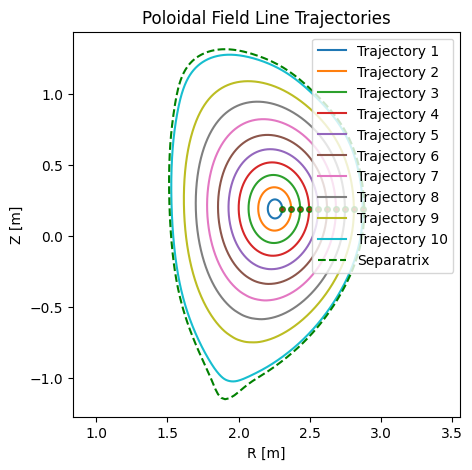

In [12]:
plt.figure(figsize=(5,5))
for i in range(len(rtraj)):
    plt.plot(rtraj[i], ztraj[i], label = f"Trajectory {i+1}")
    plt.plot(rtraj[i][0], ztraj[i][0], 'go', markersize=4, alpha=0.8)
    plt.plot(rtraj[i][-1], ztraj[i][-1], 'ro', markersize=2, alpha=0.4)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Poloidal Field Line Trajectories")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [13]:
r_grid_points, z_grid_points = psiBfield.grid_points(rtraj, ztraj)

Cumulative distances along trajectories computed.
Grid points along trajectories computed.


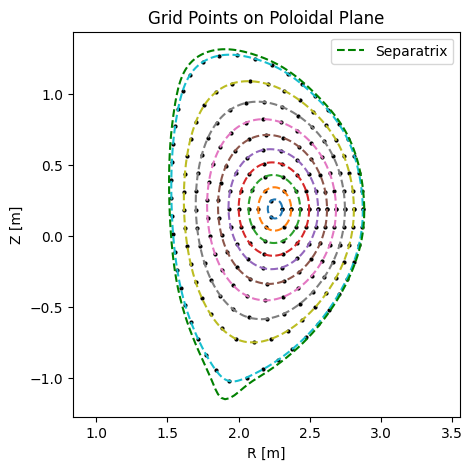

In [ ]:
plt.figure(figsize=(5,5))
for i in range(len(r_grid_points)):
    plt.plot(r_grid_points[i], z_grid_points[i], 'kx', markersize=5)
    plt.plot(rtraj[i], ztraj[i], '--')
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Grid Points on Poloidal Plane")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [15]:
r_array = np.concatenate(r_grid_points)
z_array = np.concatenate(z_grid_points)

points = np.column_stack((r_array, z_array))

from scipy.spatial import Delaunay

tri = Delaunay(points)

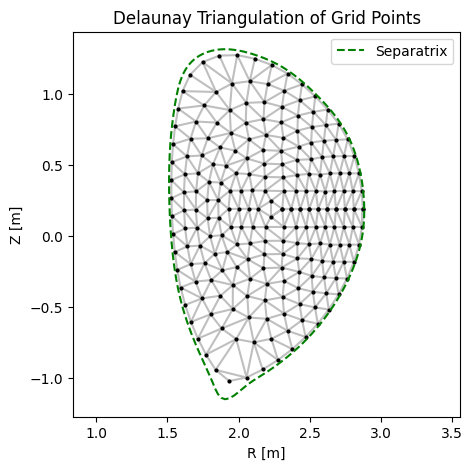

In [16]:
plt.figure(figsize=(5,5))
plt.triplot(points[:,0], points[:,1], tri.simplices, color='gray', alpha=0.5)
plt.plot(points[:,0], points[:,1], 'ko', markersize=2)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Delaunay Triangulation of Grid Points")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [17]:
points.shape

(227, 2)

In [18]:
tri.simplices

array([[ 43,  63,  42],
       [207, 164, 208],
       [210, 167, 211],
       ...,
       [ 50,  49,  32],
       [ 49,  50,  72],
       [ 71,  49,  72]], shape=(406, 3), dtype=int32)

In [19]:
distances_to_axis = []
for tri_indices in tri.simplices:
    p1, p2, p3 = points[tri_indices]

    centroid_r, centroid_z = (p1 + p2 + p3) / 3

    distance = np.sqrt((centroid_r - g.rmaxis)**2 + (centroid_z - g.zmaxis)**2)
    distances_to_axis.append(distance)

distances_to_axis

[np.float64(0.4470030623415292),
 np.float64(0.8446341788922451),
 np.float64(1.0283557767205063),
 np.float64(1.0629670233071642),
 np.float64(0.6608706607162215),
 np.float64(0.6993437115400973),
 np.float64(0.6531322927971025),
 np.float64(0.6008998050699398),
 np.float64(0.9963941630873054),
 np.float64(1.0316181914697602),
 np.float64(0.8941794014281871),
 np.float64(1.0468439167549974),
 np.float64(1.0952823915374412),
 np.float64(1.0352151455953724),
 np.float64(0.8964946287195091),
 np.float64(0.4901777163292154),
 np.float64(0.8657066516028783),
 np.float64(0.5906923429962053),
 np.float64(0.5626909383990266),
 np.float64(0.6049857644473589),
 np.float64(0.6719507967862579),
 np.float64(0.7301010486375932),
 np.float64(0.6907419942608405),
 np.float64(0.7346248375480788),
 np.float64(0.6666392065763941),
 np.float64(0.6984848500001477),
 np.float64(0.7837097652532201),
 np.float64(0.8004044360391459),
 np.float64(0.4696413342475315),
 np.float64(0.539392930927868),
 np.float64

In [22]:
hole_radius = 0.12

filtered_triangles_with_hole = []

for tri_indices in tri.simplices:
    p1, p2, p3 = points[tri_indices]

    centroid_r, centroid_z = (p1 + p2 + p3) / 3

    distance = np.sqrt((centroid_r - g.rmaxis)**2 + (centroid_z - g.zmaxis)**2)

    if distance > hole_radius:
        # print(f"Triangle with vertices {p1}, {p2}, {p3} is too close to the magnetic axis and will be removed.")
        filtered_triangles_with_hole.append(tri_indices)

filtered_triangles_with_hole = np.array(filtered_triangles_with_hole)

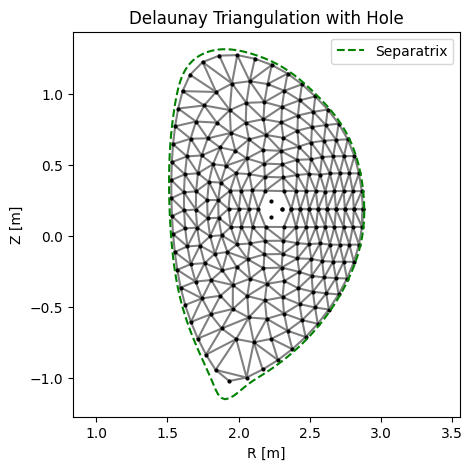

In [23]:
plt.figure(figsize=(5,5))
plt.triplot(points[:,0], points[:,1], filtered_triangles_with_hole, color='gray', markersize=2)
plt.plot(points[:,0], points[:,1], 'ko', markersize=2)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Delaunay Triangulation with Hole")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# ===================
# Interpolators
# ===================

BR_interp = RegularGridInterpolator((g.r_grid[:,0], g.z_grid[0,:]), BR)
BZ_interp = RegularGridInterpolator((g.r_grid[:,0], g.z_grid[0,:]), BZ)
psi_interp = RegularGridInterpolator((g.r_grid[:,0], g.z_grid[0,:]), psi_norm)


# =========================
# Field Line Equation
#==========================

def F(r_current, z_current):
    if not (g.rbdry.min()-0.01 <= r_current <= g.rbdry.max()+0.01 and
        g.zbdry.min()-0.01 <= z_current <= g.zbdry.max()+0.01):
        return np.nan, np.nan
    
    BR_local = BR_interp((r_current, z_current))
    BZ_local = BZ_interp((r_current, z_current))
    Bp_local = np.sqrt(BR_local**2 + BZ_local**2)
    if Bp_local == 0.0:
        br = 0.0
        bz = 0.0
    else:
        br = BR_local/Bp_local
        bz = BZ_local/Bp_local
    return br, bz


#=========================
# RK4 Implementation
#=========================

def RK4(F, r_current, z_current, h):
    k1r, k1z = F(r_current, z_current)
    if np.isnan(k1r) or np.isnan(k1z): return np.nan, np.nan

    k2r, k2z = F(r_current + 0.5*h*k1r, z_current + 0.5*h*k1z)
    if np.isnan(k2r) or np.isnan(k2z): return np.nan, np.nan

    k3r, k3z = F(r_current + 0.5*h*k2r, z_current + 0.5*h*k2z)
    if np.isnan(k3r) or np.isnan(k3z): return np.nan, np.nan

    k4r, k4z = F(r_current + h*k3r, z_current + h*k3z)
    if np.isnan(k4r) or np.isnan(k4z): return np.nan, np.nan

    r_new = r_current + (h/6)*(k1r + 2*k2r + 2*k3r + k4r)
    z_new = z_current + (h/6)*(k1z + 2*k2z + 2*k3z + k4z)
    return r_new, z_new


# =========================
# initial cinditions
# =========================

r_start = g.rbdry.max()
z_start = g.zmaxis

psi_current = psi_interp((r_start, z_start))

r_trajectory_f = []
z_trajectory_f = []

step_count = 0
diff_angle = 0.0

initial_h = -1e-6

tolerance = 1e-4

max_step = 10000000

print(f"""User inputs received. 
          r_start = {r_start},  initial_h = {initial_h}, tolerance = {tolerance}, max_step = {max_step}.
          Starting Last Field Line Tracing...""")

while (step_count < max_step):
        

        step_count += 1
        h_current_step = initial_h

        angle_initial = np.arctan2(z_start - g.zmaxis, r_start - g.rmaxis) + np.pi
        refined_step_found = False
        for _ in range(15):
            r_trial, z_trial = RK4(F, r_start, z_start, h_current_step)

            psi_trial = psi_interp((r_trial, z_trial))

            if abs(psi_trial - psi_current) < tolerance:
                refined_step_found = True
                r_start, z_start = r_trial, z_trial
                break
            else:
                h_current_step /= 2.0
                if h_current_step < 1e-10:
                    refined_step_found = True
                    r_start, z_start = r_trial, z_trial
                    break

        angle_trial = np.arctan2(z_trial - g.zmaxis, r_trial - g.rmaxis) + np.pi

        diff_angle += abs(angle_initial - angle_trial)

        if diff_angle >= 4*np.pi:
            break

        r_current, z_current = r_start, z_start

        r_trajectory_f.append(r_start)
        z_trajectory_f.append(z_start)
        print(f"Step {step_count} : r = {r_current:.4f}, z = {z_current:.4f}, psi = {psi_trial:.4f}, h = {h_current_step:.2e}")    
